In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import numpy as np
import xarray as xr
import glob 

from causaldynamics.scm import create_scm_graph
from causaldynamics.plot import plot_scm
from causaldynamics.score import score
from causaldynamics.baselines import PCMCIPlus
from causaldynamics.baselines import FPCMCI
from causaldynamics.baselines import DYNOTEARS
from causaldynamics.baselines import VARLiNGAM
from causaldynamics.baselines import NGC_LSTM
from causaldynamics.baselines import TSCI
from causaldynamics.baselines import CUTSPlus
# from causaldynamics.baselines import RCD
# from causaldynamics.baselines import GIN
# from causaldynamics.baselines import GRASP
from causaldynamics.baselines import TCDF

# DYNOTEARS / FPCMCI + not sure about PCMCIPlus + VARLiNGAM

from tqdm import tqdm
from pathlib import Path
import torch

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt 

from causaldynamics.baselines import PICABU, StructuredLowRankDiscovery, StructuredODEDiscovery

In [ ]:
DATA_DIR = Path("../data/climate/coupled_enso_modes/data")  # (you can change this to your own path)
ds = xr.open_dataset(DATA_DIR / "NONE_N10_T1000.nc")

# NOTE: If dataset is from coupled system e.g., "../data/coupled/...", follow these changes to load the data:
timeseries = ds['time_series'].to_numpy()[..., 0].transpose(1, 0, 2) ## select the first dimension of each multidimensional node
adj_matrix = ds['adjacency_matrix'].to_numpy() ## `adjacency_matrix_summary` is the true adjacency matrix for coupled system

n_systems = adj_matrix.shape[0]

KeyError: "No variable named 'adjacency_matrix_summary'. Did you mean one of ('adjacency_matrix',)?"

In [4]:
glob.glob("../data/climate/coupled_enso_modes/data/*")

['../data/climate/coupled_enso_modes/data/ExPO_N10_T1000.nc',
 '../data/climate/coupled_enso_modes/data/ATL3_N10_T1000.nc',
 '../data/climate/coupled_enso_modes/data/NPMM_N10_T1000.nc',
 '../data/climate/coupled_enso_modes/data/TNA_N10_T1000.nc',
 '../data/climate/coupled_enso_modes/data/AO_N10_T1000.nc',
 '../data/climate/coupled_enso_modes/data/SPMM_N10_T1000.nc',
 '../data/climate/coupled_enso_modes/data/SASD_N10_T1000.nc',
 '../data/climate/coupled_enso_modes/data/SIOD_N10_T1000.nc',
 '../data/climate/coupled_enso_modes/data/IO_N10_T1000.nc',
 '../data/climate/coupled_enso_modes/data/IOB_N10_T1000.nc',
 '../data/climate/coupled_enso_modes/data/NONE_N10_T1000.nc']

In [4]:
adj_matrix

array([[1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [6]:
# for k in range(1):
    
#     timeseries_norm = timeseries[k]
#     timeseries_norm -= timeseries_norm.mean(0)
#     timeseries_norm /= timeseries_norm.std(0)
    
#     plt.figure()
# #     for j in range(5):
# #     plt.plot(timeseries_norm[:, 6], c = 'orange')
# #     plt.plot(timeseries_norm[:, 7], c = 'blue')
#     plt.plot(np.diff(timeseries_norm[:, 7]), c = 'blue')

# #     plt.plot(timeseries_norm[:, 8], c = 'green')
#     plt.plot(np.diff(timeseries_norm[:, 8]), c = 'green')
    
#     plt.plot(np.diff(timeseries_norm[:, 6]), c = 'orange')

#     plt.show()
#     plt.close()


In [7]:
# for k in range(1):
    
#     timeseries_norm = timeseries[k]
#     timeseries_norm -= timeseries_norm.mean(0)
#     timeseries_norm /= timeseries_norm.std(0)
    
#     plt.figure()
#     for j in range(4):
#         plt.plot(np.diff(timeseries_norm[:, j]))
#     plt.show()
#     plt.close()


In [8]:
adj_matrix

array([[1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.]])

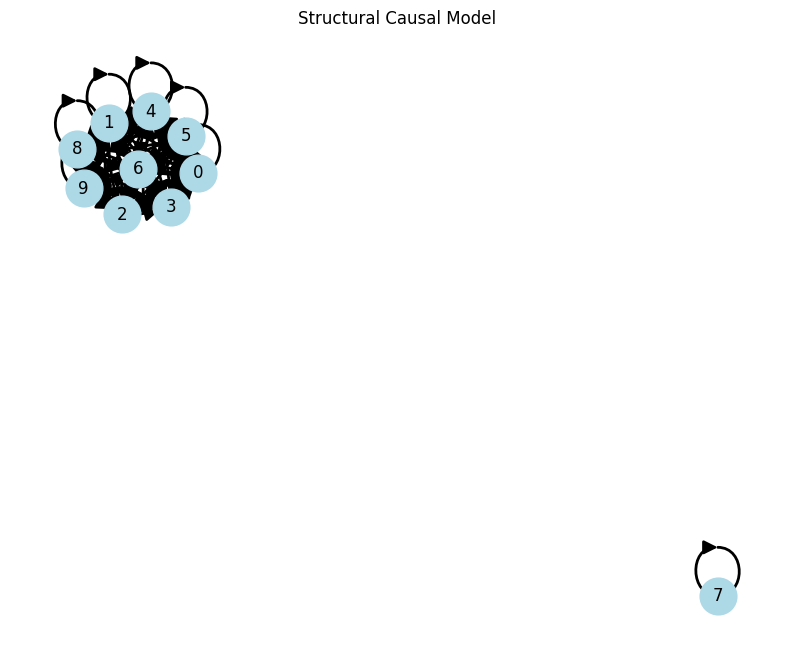

In [9]:
G = create_scm_graph(adj_matrix)
plot_scm(G);


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [17]:
hyperparam_search_array = np.array([0.001, 0.0025, 0.005,  0.0075, 0.01, 0.025, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75, 1.0])
hyperparam_search_array[5]

0.025

In [13]:
np.load('../scripts/shd_results.npy').argmin()

6

In [16]:
np.load('../scripts/auprc_results.npy')[:10].argmax()

5

In [18]:
np.load('../scripts/auroc_results.npy')[:10]

array([[0.62185185],
       [0.62790123],
       [0.64141975],
       [0.63876543],
       [0.63518519],
       [0.68969136],
       [0.66530864],
       [0.65074074],
       [0.66388889],
       [0.67506173]])

In [ ]:
tau_max = 1 # i.e. no delay 

## Estimate adjacency matrix
lowrank_adj_matrix = []

all_shd = []
all_auroc = []
all_auprc = []

lambda_m_hp = 0.75

for x in timeseries[:, :, None]:
    lowrank_model = StructuredODEDiscovery(
        coupled=False,
        t = tau_max,
        n = n_systems,
        L_lipschitz = 1, 
        is_lipschitz = False,
        hidden_dim = 8, 
        n_layers = 2,
        device = device,
        beta_init = 0.33, 
        beta_min = 0.33,
        annealing_rate = 0.95,
        annealing_epochs = 10,
        normalize_grad = True,
    )
    trained_model, mask = lowrank_model.run(n_samples=3, lambda_grad=100, X=torch.tensor(x).to(device), l0_l1_l2='l0', th=0.5, lr=0.001, lambda_m = lambda_m_hp, n_inner_min_sparse = 100, batch_size=128, n_inner=4_000, patience = 500, save_fig_path="coupled_atmos_ocean_loss.png")
    lowrank_adj_matrix.append(mask.detach().cpu().numpy())
#     lowrank_S_matrix.append(copy.deepcopy(lowrank_model.model.S))
    
    coupled = False

    mask_numpy = mask.detach().cpu().numpy()

    if coupled:
        vec = (mask_numpy > 0.1).sum(1) == 0
        if np.any(vec):
            idx = np.flatnonzero(vec)
            mask_numpy[0, idx, idx] = 1


    results_scores = score(
        preds= mask_numpy, #.transpose((0, 2, 1)), # Need to transpos
        labs= adj_matrix,
        name='LR_discovery'
    )

    print(results_scores)

    all_shd.append(results_scores.loc["Joint SHD", "LR_discovery"])
    all_auroc.append(results_scores.loc["Joint AUROC", "LR_discovery"])
    all_auprc.append(results_scores.loc["Joint AUPRC", "LR_discovery"])

results_scores = score(
    preds= np.array(lowrank_adj_matrix)[:, 0], #.transpose((0, 2, 1)), # Need to transpos
    labs= adj_matrix,
    name='LR_discovery'
)



Dimensions: N=10, T=1
Number of NaN values in X: False
Number of NaN values after normalization in X: False
Constant dimensions in X: (tensor([], device='cuda:0', dtype=torch.int64),)
X_t_all.shape: torch.Size([999, 1, 10])
X_last_all.shape: torch.Size([999, 1, 10])
recon=0.6558  |M|_1=79.351  grad_penalty=0.0002  
Scoring...
                  LR_discovery
Metric                        
Joint AUROC           0.476933
Individual AUROC      0.476933
Null AUROC            0.500000
Joint AUPRC           0.814092
Individual AUPRC      0.814092
Null AUPRC            0.810000
Joint SHD            24.000000
Dimensions: N=10, T=1
Number of NaN values in X: False
Number of NaN values after normalization in X: False
Constant dimensions in X: (tensor([], device='cuda:0', dtype=torch.int64),)
X_t_all.shape: torch.Size([999, 1, 10])
X_last_all.shape: torch.Size([999, 1, 10])
recon=0.6404  |M|_1=75.284  grad_penalty=0.0002  
Scoring...
                  LR_discovery
Metric                        
Joi

In [ ]:
# TNA_N10_T1000 --> 

results_scores = score(
    preds= np.array(lowrank_adj_matrix)[:, 0], #.transpose((0, 2, 1)), # Need to transpos
    labs= adj_matrix,
    name='LR_discovery'
)





In [13]:
mask_numpy * 1000 // 10 / 100

array([[[0.  , 0.32, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.2 , 0.  , 0.  , 0.  , 0.01, 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.04],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]]],
      dtype=float32)

In [21]:
coupled = False

mask_numpy = mask.detach().cpu().numpy()

if coupled:
    vec = (mask_numpy > 0.1).sum(1) == 0
    if np.any(vec):
        idx = np.flatnonzero(vec)
        mask_numpy[0, idx, idx] = 1


results_scores = score(
    preds= mask_numpy, #.transpose((0, 2, 1)), # Need to transpos
    labs= adj_matrix,
    name='LR_discovery'
)

print(results_scores)


Scoring...
                  LR_discovery
Metric                        
Joint AUROC           0.389864
Individual AUROC      0.389864
Null AUROC            0.500000
Joint AUPRC           0.772857
Individual AUPRC      0.772857
Null AUPRC            0.810000
Joint SHD            26.000000


In [81]:
adj_matrix

array([[1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 0., 1., 1.]])

In [82]:
mask_numpy

array([[[6.3046139e-01, 8.0834424e-01, 6.6168433e-01, 4.6213907e-01,
         8.5158587e-01, 8.2559091e-01, 2.9388573e-06, 7.4032187e-01,
         7.6826566e-01, 7.2262448e-01],
        [7.9474485e-01, 2.5864628e-01, 4.0875852e-01, 2.1801549e-01,
         7.8114098e-01, 7.3359489e-01, 2.8253392e-06, 5.6130797e-01,
         6.7460924e-01, 7.3741525e-01],
        [4.0388745e-01, 2.4809086e-01, 6.4926350e-01, 6.3293141e-01,
         6.6573441e-01, 7.1432966e-01, 2.7983308e-06, 6.4920247e-01,
         5.7962477e-01, 5.5552089e-01],
        [3.4509689e-04, 1.5692867e-03, 4.2056829e-01, 7.2530979e-01,
         5.4834783e-01, 7.4545097e-01, 2.7146832e-06, 5.2127445e-01,
         7.8538930e-01, 5.7321823e-01],
        [6.3400060e-01, 3.2139853e-01, 5.6305087e-01, 6.6595441e-01,
         7.9695123e-01, 7.1488988e-01, 2.7837975e-06, 4.6352783e-01,
         7.6817030e-01, 5.0944704e-01],
        [6.0979754e-01, 5.9018767e-04, 6.9905907e-01, 7.0637769e-01,
         7.9879409e-01, 8.2996082e-01, 2.